# Phân tích và khám phá dữ liệu (EDA)
Bộ dữ liệu: **Dry Bean Dataset** - file `Dry_Bean_Dataset.xlsx`

## Giới thiệu bộ dữ liệu:
Bộ dữ liệu **Dry Bean Dataset** ghi nhận thông tin đặc trưng hình học của các hạt đậu khô, được thu thập thông qua hệ thống computer vision từ ảnh chụp độ phân giải cao. Dữ liệu phục vụ cho bài toán phân loại các loại đậu khác nhau dựa trên hình dạng và kích thước.

## Thông tin chi tiết:
* **Tập dữ liệu sử dụng:** Tập dữ liệu sử dụng: Gồm 13.611 mẫu (hạt đậu).

* **Biến mục tiêu (Target):** `Class` (7 loại đậu: `Seker`, `Barbunya`, `Bombay`, `Cali`, `Dermosan`, `Horoz`, `Sira`).

* **Các đặc trưng (Features):**
Bao gồm 16 đặc trưng số học, được chia thành:

  - **Đặc trưng kích thước:** diện tích, chu vi, trục lớn/nhỏ,...

  - **Đặc trưng hình dạng:** độ tròn, độ gọn, độ lệch tâm, các hệ số hình dạng,... 


  Cụ thể như sau:
    1. `Area` (A): Diện tích vùng hạt (số pixel)

    2. `Perimeter` (P): Chu vi của hạt

    3. `MajorAxisLength` (L): Độ dài trục lớn nhất

    4. `MinorAxisLength` (l): Độ dài trục nhỏ nhất (vuông góc với trục lớn)

    5. `AspectRatio` (K): Tỷ lệ giữa trục lớn và trục nhỏ (L/l)

    6. `Eccentricity` (Ec): Độ lệch tâm của elip tương đương

    7. `ConvexArea` (C): Diện tích bao lồi nhỏ nhất chứa hạt

    8. `EquivalentDiameter` (Ed): Đường kính của hình tròn có cùng diện tích

    9. `Extent` (Ex): Tỷ lệ diện tích hạt so với bounding box

    10. `Solidity` (S): Tỷ lệ giữa diện tích hạt và diện tích bao lồi

    11. `Roundness` (R): Độ tròn của hạt

    12. `Compactness` (CO): Độ “gọn” của hình (Ed/L)

    13. `ShapeFactor1` (SF1)

    14. `ShapeFactor2` (SF2)

    15. `ShapeFactor3` (SF3)

    16. `ShapeFactor4` (SF4)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Xác định ROOT: thư mục chứa 'data/'
try:
    ROOT = Path(__file__).resolve().parent.parent
except NameError:
    cwd = Path.cwd()
    for candidate in [cwd, cwd.parent, cwd.parent.parent]:
        if (candidate / "data").exists():
            ROOT = candidate
            break
    else:
        raise FileNotFoundError(f"Không tìm thấy thư mục 'data/' từ {cwd}")

DATA_DIR = ROOT / "data" / "classification"

print(f"ROOT     : {ROOT}")
print(f"DATA_DIR : {DATA_DIR}")
assert (DATA_DIR / "Dry_Bean_Dataset.xlsx").exists(), f"Không tìm thấy {DATA_DIR / 'Dry_Bean_Dataset.xlsx'}"

plt.rcParams["figure.dpi"] = 120

ROOT     : /home/lesliu/Documents/school/25_26_Semester_2/intro2ml/lab1
DATA_DIR : /home/lesliu/Documents/school/25_26_Semester_2/intro2ml/lab1/data/classification


## 1. Đọc và tổng quan dữ liệu

In [3]:
df = pd.read_excel(DATA_DIR / "Dry_Bean_Dataset.xlsx")
print(f"Kích thước: {df.shape[0]} mẫu, {df.shape[1]} cột")
df.head()

Kích thước: 13611 mẫu, 17 cột


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

Kiểm tra giá trị thiếu:

In [5]:
missing = df.isnull().sum()
print("Số giá trị thiếu theo cột:")
print(missing[missing > 0] if missing.any() else "Không có giá trị thiếu.")

Số giá trị thiếu theo cột:
Không có giá trị thiếu.


## 2. Thống kê mô tả:


In [6]:
FEATURES = ["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength", 
            "AspectRation", "Eccentricity", "ConvexArea", "EquivDiameter", 
            "Extent", "Solidity", "roundness", "Compactness", "ShapeFactor1",
            "ShapeFactor2", "ShapeFactor3", "ShapeFactor4"]
TARGET = "Class"

stat = stat = df[FEATURES].describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
]
stat.columns = ["Trung bình", "Độ lệch chuẩn", "Min", "Q1", "Trung vị", "Q3", "Max"]
stat.round(4)

,Trung bình,Độ lệch chuẩn,Min,Q1,Trung vị,Q3,Max
Area,53048.2845,29324.0957,20420.0000,36328.0000,44652.0000,61332.0000,254616.0000
Perimeter,855.2835,214.2897,524.7360,703.5235,794.9410,977.2130,1985.3700
MajorAxisLength,320.1419,85.6942,183.6012,253.3036,296.8834,376.4950,738.8602
MinorAxisLength,202.2707,44.9701,122.5127,175.8482,192.4317,217.0317,460.1985
AspectRation,1.5832,0.2467,1.0249,1.4323,1.5511,1.7071,2.4303
Eccentricity,0.7509,0.0920,0.2190,0.7159,0.7644,0.8105,0.9114
ConvexArea,53768.2002,29774.9158,20684.0000,36714.5000,45178.0000,62294.0000,263261.0000
EquivDiameter,253.0642,59.1771,161.2438,215.0680,238.4380,279.4465,569.3744
Extent,0.7497,0.0491,0.5553,0.7186,0.7599,0.7869,0.8662
Solidity,0.9871,0.0047,0.9192,0.9857,0.9883,0.9900,0.9947


**Nhận xét về bảng Thống kê mô tả:**

- **Khác biệt lớn về thang đo (Scale):** Các đặc trưng về kích thước (`Area`, `ConvexArea`, `Perimeter`, `EquivDiameter`) chạy trên dải rộng, với độ lệch chuẩn rất lớn. Ngược lại, các chiều tỉ lệ như (`ShapeFactor1-4`, `Solidity`, `Extent`, `roundness`) hầu hết được giới hạn tự nhiên trong không gian nhỏ [0, 1]. Đây là hệ quả cho việc chúng ta **chắc chắn phải có bước chuẩn hóa dữ liệu (Standardization/Normalization)** nhằm giúp cho các mô hình tuyến tính (ví dụ Logistic Regression) hội tụ hiệu quả hơn, không bị thiên vị bởi một biến mang trị số lớn.

- **Ngoại lai và phân bố lệch phải (Skewness & Outlier):** Trong các biến kích thước kể trên (`Area`, `ConvexArea`), quan sát thấy giá trị Max trội vọt so với Q3 và giá trị Trung bình (nhiều gấp 3, gấp 4 lần). Đây là dấu hiệu của phân bố lệch phải, ám chỉ sự xuất hiện của các hạt đậu có kích cỡ khổng lồ so với phần đông bộ dữ liệu, có thể là các điểm ngoại lai.

- **Hình thái học độ đặc:** Biên độ tự nhiên của kích cỡ là rất đa dạng, tuy nhiên đa số hạt đậu trong tập lại khá đặc và lồi nguyên vẹn, do giá trị `Solidity` (Tỉ lệ khối lượng lấp đầy thân lồi) tập trung tiệm cận tối đa nằm ở dải siêu hẹp (Min = 0.919, Max = 0.994). Cùng chung đó, độ thuôn `Eccentricity` và `AspectRation` có biên độ dao động rộng chứng tỏ chia rải đều cho các loại đậu đa dạng hình thù.

## 3. Phân bố biến mục tiêu Class

/tmp/ipykernel_172082/3887200509.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


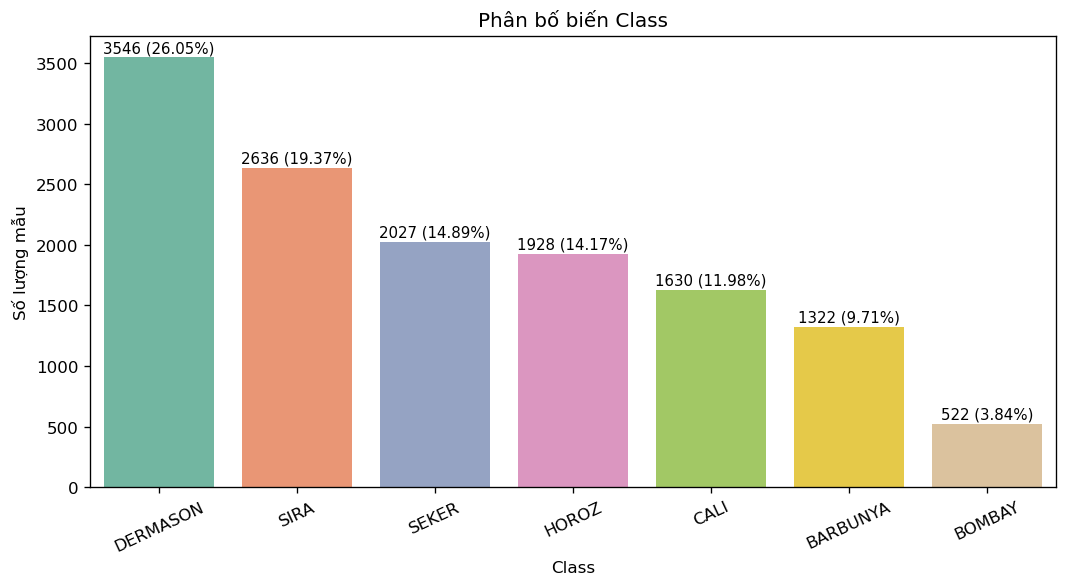

,Số lượng,Tỷ lệ (%)
Class,,
DERMASON,3546,26.05
SIRA,2636,19.37
SEKER,2027,14.89
HOROZ,1928,14.17
CALI,1630,11.98
BARBUNYA,1322,9.71
BOMBAY,522,3.84


In [7]:
class_counts = df["Class"].value_counts().sort_values(ascending=False)
class_ratio = (class_counts / class_counts.sum() * 100).round(2)

plt.figure(figsize=(9, 5))
ax = sns.countplot(
    data=df,
    x="Class",
    order=class_counts.index,
    palette="Set2"
 )
ax.set_title("Phân bố biến Class")
ax.set_xlabel("Class")
ax.set_ylabel("Số lượng mẫu")
plt.xticks(rotation=25)

for i, cls_name in enumerate(class_counts.index):
    count = class_counts[cls_name]
    ratio = class_ratio[cls_name]
    ax.text(i, count + 20, f"{count} ({ratio}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

pd.DataFrame({
    "Số lượng": class_counts,
    "Tỷ lệ (%)": class_ratio
})

**Nhận xét về Phân bố biến mục tiêu (Class):**

- **Sự mất cân bằng dữ liệu (Imbalanced Data):** Phân bố số lượng mẫu giữa 7 giống hạt đậu có sự chênh lệch rõ rệt. Giống `DERMASON` chiếm đa số với tỷ trọng lớn nhất là 26.05% (3546 mẫu), trong khi giống `BOMBAY` lại chiếm nhóm thiểu số, ở mức rất thấp chỉ 3.84% (522 mẫu). Nhóm lớn nhất đông gấp gần 7 lần so với nhóm ít nhất.

- **Thách thức cho mô hình học máy:** Việc dữ liệu bị mất cân bằng trầm trọng có thể khiến mô hình nảy sinh thiên kiến (bias) — tức là mô hình sẽ dễ dàng đưa ra dự đoán tốt trên các nhóm đa số (DERMASON, SIRA, SEKER) nhưng lại nhận diện rất kém đối với nhóm thiểu số (BOMBAY) do không có đủ dữ liệu để học.

- **Giải pháp đề xuất:** Khi huấn luyện các thuật toán phân lớp, cần kiểm tra kỹ lại độ đo hiệu năng trên từng lớp riêng biệt (chẳng hạn dùng F1-Score thay vì chỉ dùng Accuracy). Đồng thời, ta có thể phải áp dụng kỹ thuật cân bằng dữ liệu như gán trọng số lớp (Class Weights), Sinh thêm dữ liệu (Oversampling/SMOTE) hoặc Lọc bớt (Undersampling) để cải thiện điểm số chung.

## 4. Ma trận tương quan (Correlation Matrix)
Biểu diễn sự tương quan tuyến tính giữa các đặc trưng số học.

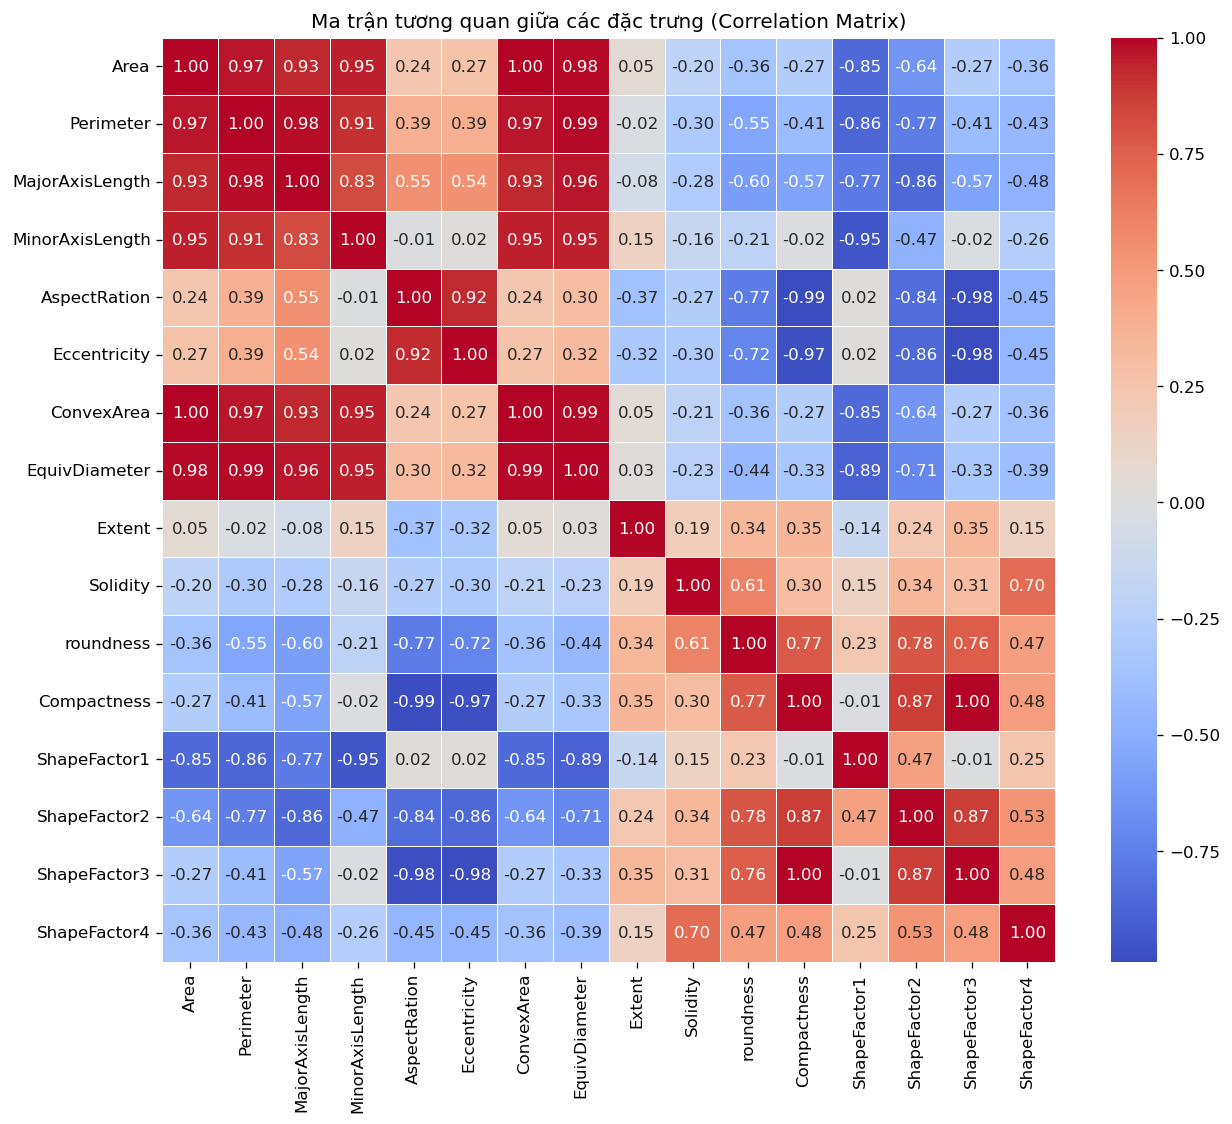

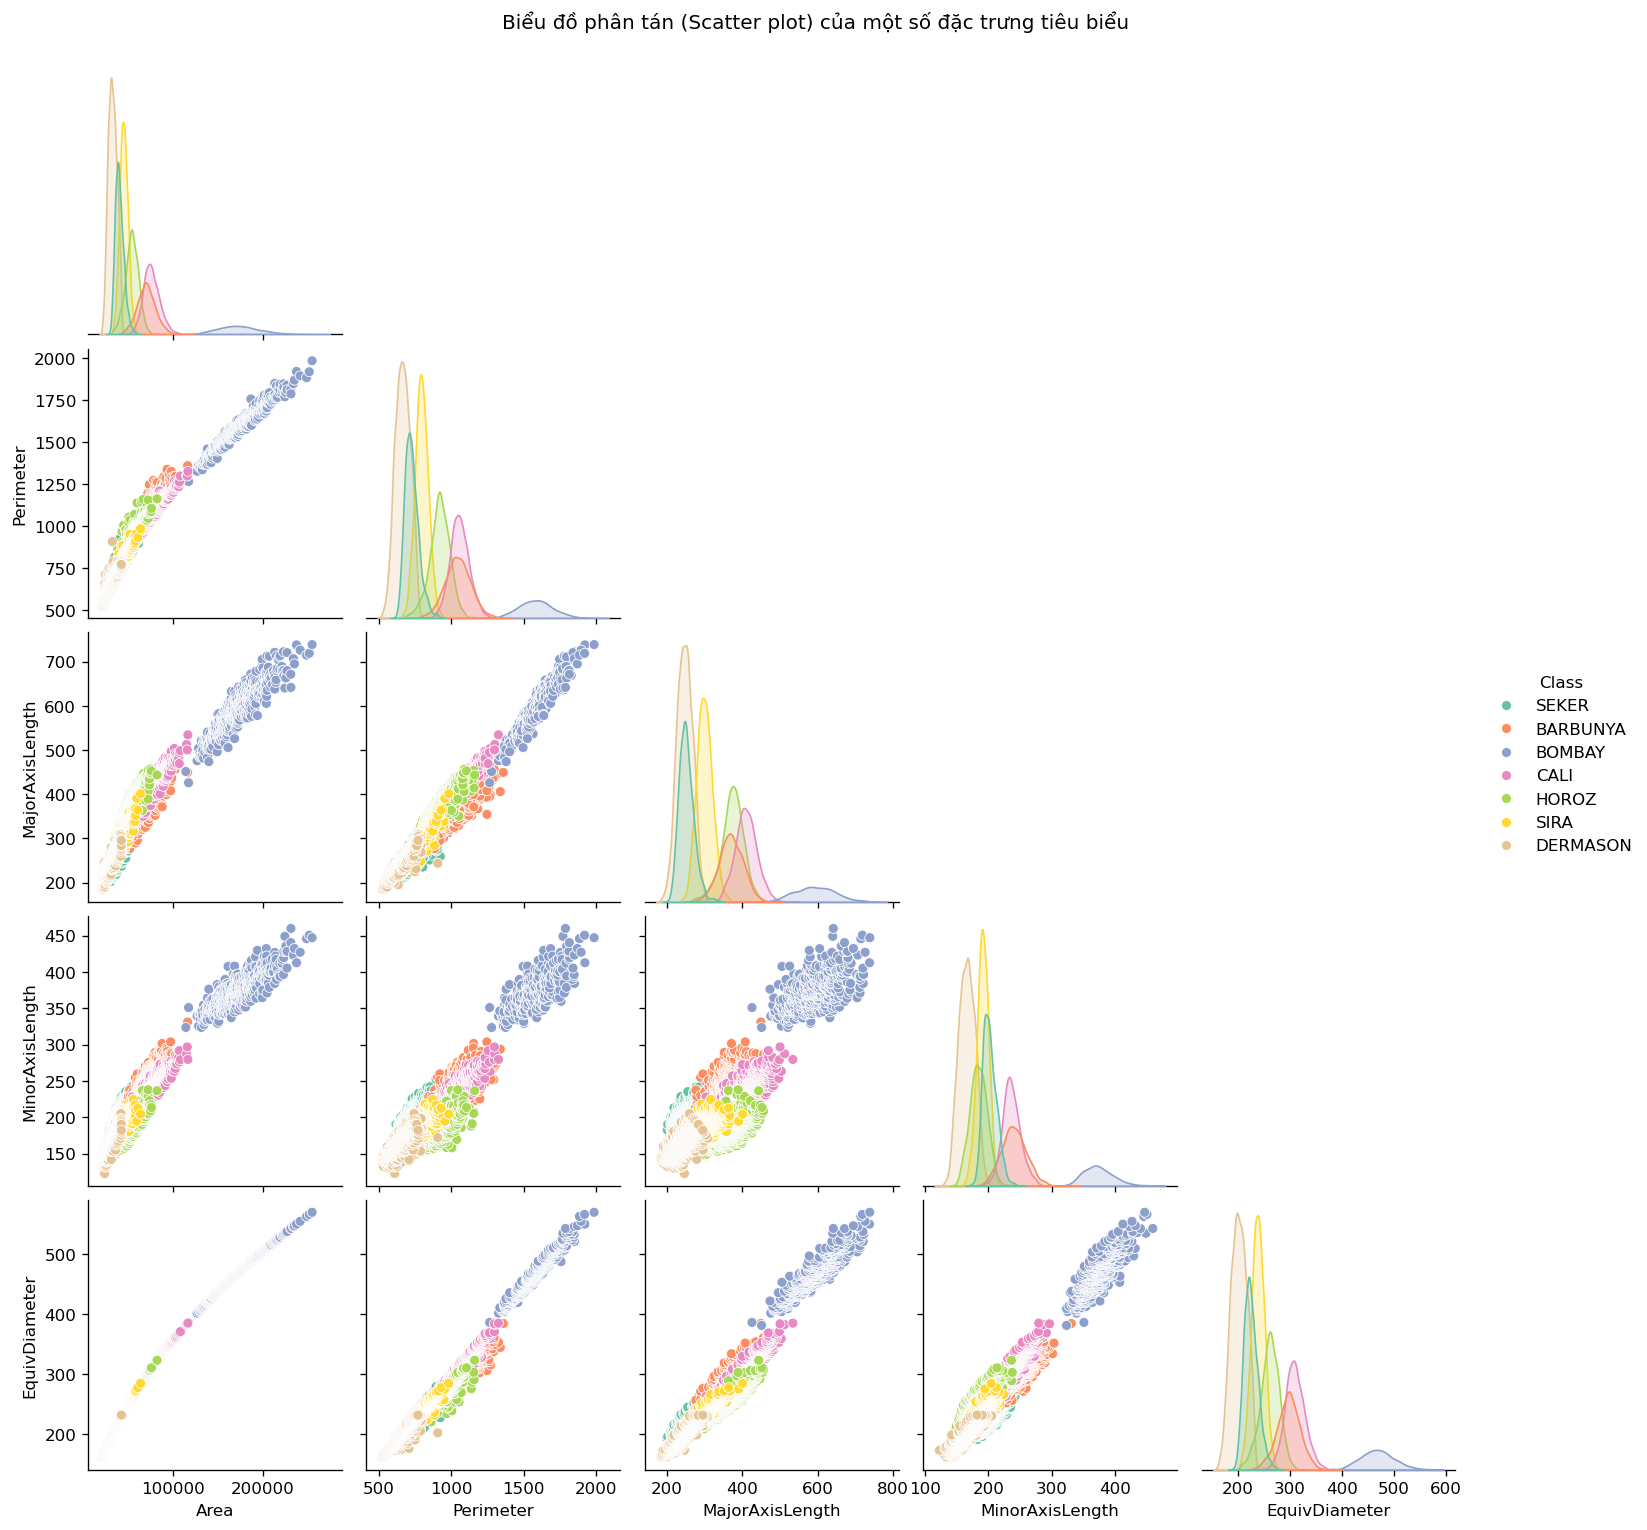

In [8]:
# Tính ma trận tương quan cho các biến đầu vào
numeric_df = df[FEATURES]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Ma trận tương quan giữa các đặc trưng (Correlation Matrix)")
plt.show()

# Biểu đồ Pairplot (thể hiện scatter các cặp biến quan trọng hoặc có tính tương quan cao)
# Việc hiển thị toàn bộ 16 biến sẽ bị quá tải, nên chúng ta sẽ chọn một số cặp biến đặc trưng kích thước nổi bật
high_corr_features = ["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength", "EquivDiameter"]
sns.pairplot(df[high_corr_features + ["Class"]], hue="Class", corner=True, palette="Set2")
plt.suptitle("Biểu đồ phân tán (Scatter plot) của một số đặc trưng tiêu biểu", y=1.02)
plt.show()


**Nhận xét về Phân tích Đa biến (Multivariate Analysis):**

1. **Ma trận tương quan (Correlation Matrix):**
- **Hiện tượng Đa cộng tuyến (Multicollinearity):** Nhóm các đặc trưng mang tính chất kích cỡ bề mặt (`Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `ConvexArea`, `EquivDiameter`) có hệ số tương quan tuyến tính thuận với nhau ở mức gần như tuyệt đối (từ 0.95 đến 1.00). Bên cạnh đó, một số biến tỷ lệ như `Compactness`, `AspectRation`, `Eccentricity` cũng cho thấy tương quan nghịch ở mức cực kỳ trần (giá trị xấp xỉ -0.99).
- **Tác động đến mô hình:** Sự xuất hiện của các dải hệ số tương quan mạnh như vậy dự báo rủi ro về đa cộng tuyến. Nếu áp dụng thẳng dữ liệu vào các mô hình tham số (Parametric) như Logistic Regression, hiện tượng này sẽ làm nhiễu hoặc sai lệch điểm ước lượng trọng số. Giải pháp hướng tới là anh có thể loại bỏ bớt các biến dư thừa (Feature Selection), giảm chiều (PCA) hoặc nhất thiết phải cài đặt cơ chế phạt trọng số (L1/L2 Regularization).

2. **Biểu đồ phân tán (Pair/Scatter Plot):**
- Phân bố về không gian đa chiều cho thấy các lớp hạt đậu tụ lại thành các vùng (cluster) có thể phân tách được bằng thuật toán học máy. Ấn tượng nhất là hạt `BOMBAY` - lớp bóc tách và phân luồng ra rõ rệt ở khung ngoại biên vì thông số kích thước lớn hơn chủng khác rất nhiều.
- Ở chiều ngược lại, khu vực có mật độ dày và nhỏ bé hơn phản ánh sự chồng chéo giữa những loài như `DERMASON`, `SIRA` hay `SEKER`. Tức là nếu mô hình chỉ học qua các thông số về độ dài/chu vi thì vẫn sẽ gặp khó khăn. Do vậy, tập hợp các đặc trưng về tỷ lệ định dạng khối (như `ShapeFactor`, `Extent`, `Solidity`) là mảnh ghép quan trọng để các mô hình bóc tách tiếp các ca chồng lấn này.

**Nhận xét về Phân tích Đa biến (Multivariate Analysis):**

1. **Ma trận tương quan (Correlation Matrix):**
- **Hiện tượng Đa cộng tuyến (Multicollinearity):** Nhóm các đặc trưng mang tính chất kích cỡ bề mặt (`Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `ConvexArea`, `EquivDiameter`) có hệ số tương quan tuyến tính thuận với nhau ở mức gần như tuyệt đối (từ 0.95 đến 1.00). Bên cạnh đó, một số biến tỷ lệ như `Compactness`, `AspectRation`, `Eccentricity` cũng cho thấy tương quan nghịch ở mức cực kỳ trần (giá trị xấp xỉ -0.99).
- **Tác động đến mô hình:** Sự xuất hiện của các dải hệ số tương quan mạnh như vậy dự báo rủi ro về đa cộng tuyến. Nếu áp dụng thẳng dữ liệu vào các mô hình tham số (Parametric) như Logistic Regression, hiện tượng này sẽ làm nhiễu hoặc sai lệch điểm ước lượng trọng số. Giải pháp hướng tới là anh có thể loại bỏ bớt các biến dư thừa (Feature Selection), giảm chiều (PCA) hoặc nhất thiết phải cài đặt cơ chế phạt trọng số (L1/L2 Regularization).

2. **Biểu đồ phân tán (Pair/Scatter Plot):**
- Phân bố về không gian đa chiều cho thấy các lớp hạt đậu tụ lại thành các vùng (cluster) có thể phân tách được bằng thuật toán học máy. Ấn tượng nhất là hạt `BOMBAY` - lớp bóc tách và phân luồng ra rõ rệt ở khung ngoại biên vì thông số kích thước lớn hơn chủng khác rất nhiều.
- Ở chiều ngược lại, khu vực có mật độ dày và nhỏ bé hơn phản ánh sự chồng chéo giữa những loài như `DERMASON`, `SIRA` hay `SEKER`. Tức là nếu mô hình chỉ học qua các thông số về độ dài/chu vi thì vẫn sẽ gặp khó khăn. Do vậy, tập hợp các đặc trưng về tỷ lệ định dạng khối (như `ShapeFactor`, `Extent`, `Solidity`) là mảnh ghép quan trọng để các mô hình bóc tách tiếp các ca chồng lấn này.

## 5. Phân tích phân bố các đặc trưng và Phát hiện Ngoại lai (Outliers)
Sử dụng **Boxplot** để trực quan hóa giá trị phân phối của các chiều. Sau đó, sử dụng phương pháp **IQR (Interquartile Range)** để đếm số lượng ngoại lai trong từng đặc trưng.

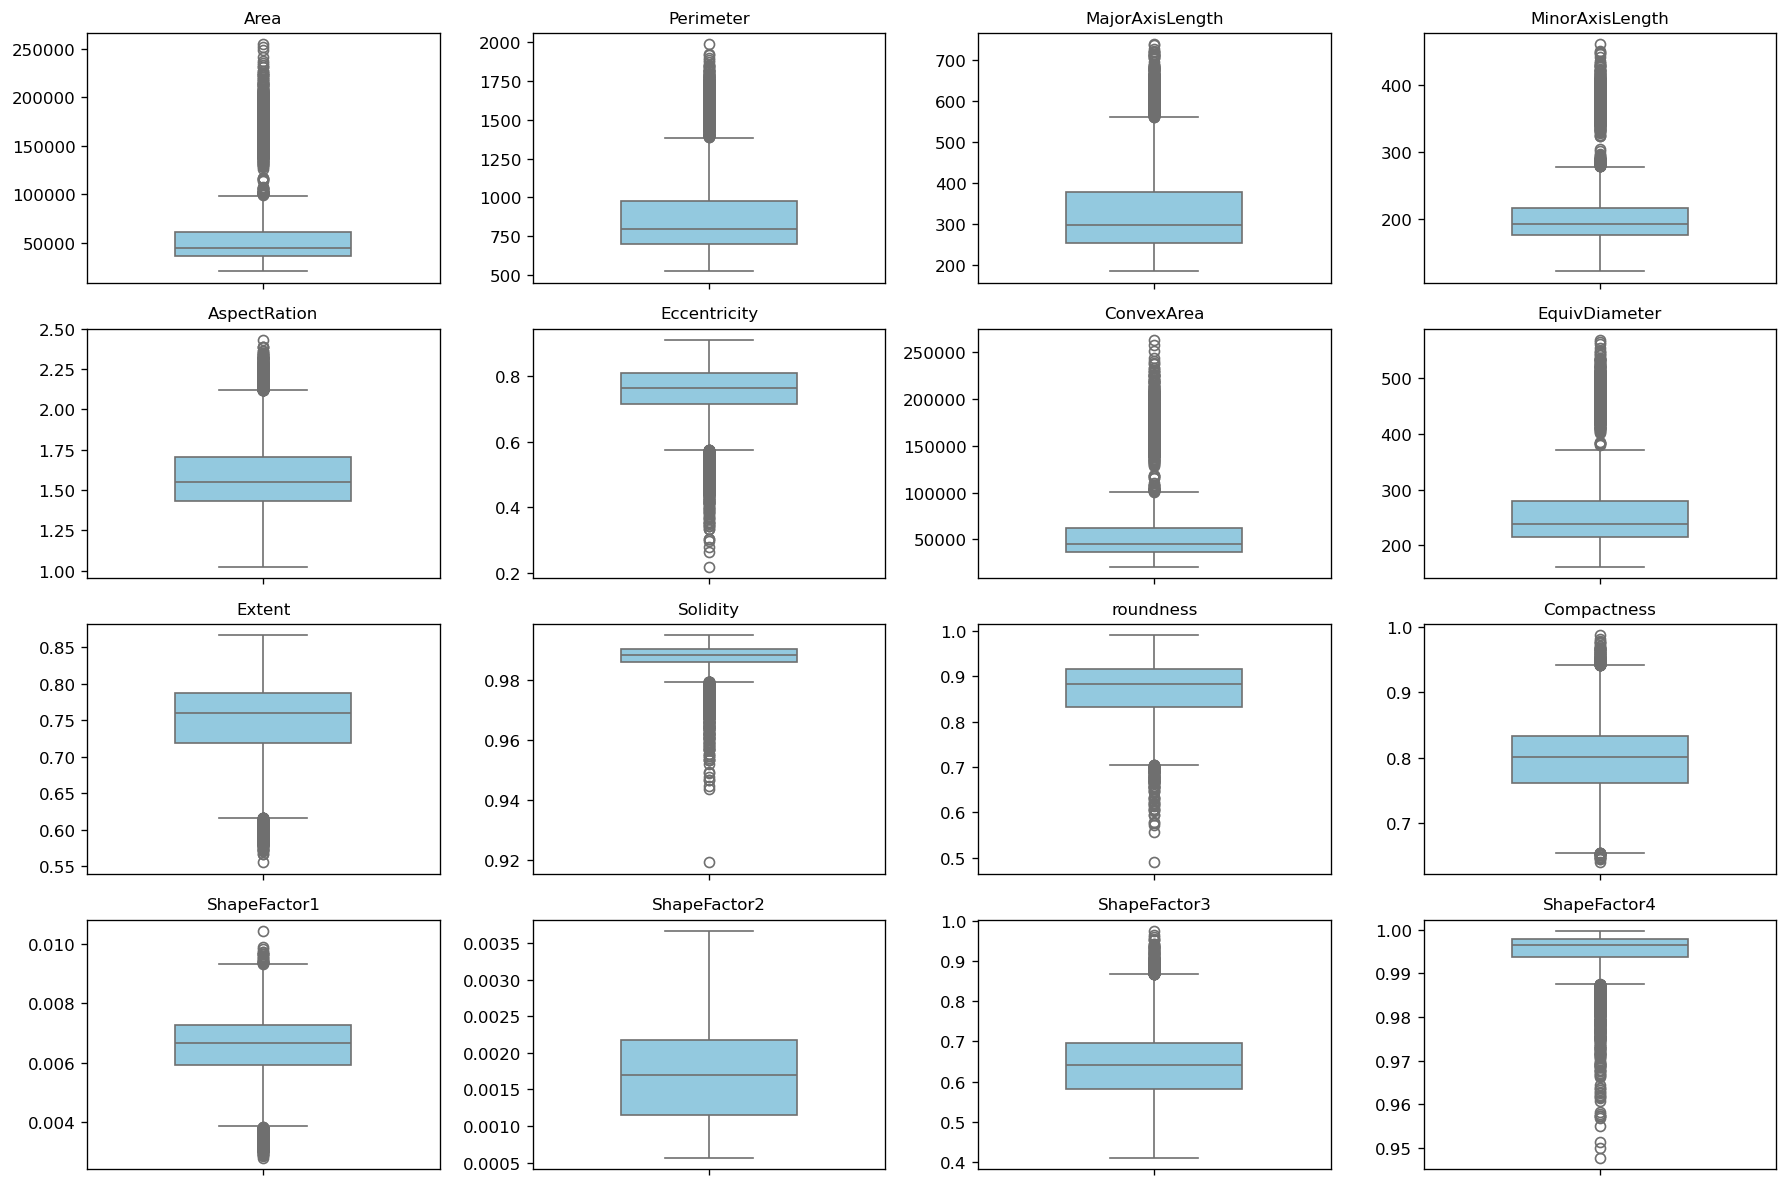

In [9]:
# Vẽ Boxplot cho từng đặc trưng
plt.figure(figsize=(15, 10))
for i, feature in enumerate(FEATURES, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[feature], width=0.5, color='skyblue')
    plt.title(feature, fontsize=10)
    plt.ylabel("")
plt.tight_layout()
plt.show()


In [10]:
# Đếm số ngoại lai bằng công thức IQR
outlier_counts = {}
for col in FEATURES:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Số lượng ngoại lai (outliers)
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=["Feature", "Outlier_Count"])
outlier_df["Percentage (%)"] = (outlier_df["Outlier_Count"] / len(df) * 100).round(2)
outlier_df = outlier_df.sort_values(by="Outlier_Count", ascending=False).reset_index(drop=True)
outlier_df


,Feature,Outlier_Count,Percentage (%)
0,Eccentricity,843,6.19
1,Solidity,778,5.72
2,ShapeFactor4,767,5.64
3,MinorAxisLength,569,4.18
4,Area,551,4.05
5,ConvexArea,550,4.04
6,ShapeFactor1,533,3.92
7,EquivDiameter,526,3.86
8,Perimeter,500,3.67
9,AspectRation,473,3.48


**Nhận xét về Phân bố đặc trưng và Ngoại lai (Outliers):**

1. **Phân bố chung và Mức độ lệch (Skewness):**
- Dựa vào các Boxplot, anh sẽ thấy đặc điểm của các biến đo lường kích thước (`Area`, `Perimeter`, `MajorAxisLength`, `ConvexArea`, `EquivDiameter`, `AspectRation`) đa phần đều bị **lệch phải tương đối mạnh (positive-skewed)**. Do sự xuất hiện dày đặc của các điểm cực lớn khiến râu trên của hộp vươn rất dài.
- Trái lại, các biến đo lường tỉ lệ, độ tròn hay định dạng hẹp (như `Solidity`, `roundness`, `Compactness`, `Extent`, `ShapeFactor3`, `ShapeFactor4`) lại đổ xô về **lệch trái (negative-skewed)** khi các dị điểm đâm lủng phần râu tụ ở ngàm dưới đáy.

2. **Tình trạng phân mảnh Ngoại lai:**
- Ngoại trừ `ShapeFactor2` có boxplot cực "sạch sẽ" (0% ngoại lai), thì toàn bộ các đặc trưng khác đều tiềm ẩn các mốc dị biệt rải rác dao động quanh mức 3 - 6% của toàn bộ dữ liệu. Điển hình và chiếm tỷ trọng lớn nhất trên 5% gồm `Eccentricity` (6.19%), `Solidity` (5.72%) và `ShapeFactor4` (5.64%).

3. **Lựa chọn hướng đi cho Machine Learning:**
- Với số liệu phản ánh sự đa dạng tự nhiên rải từ các loại hạt giống nhỏ tới loại hạt khổng lồ (mẫu lớn dị biệt như BOMBAY), tần suất xuất hiện ngoại lai cao là **có thực và hoàn toàn ý nghĩa** để mô hình nhận dạng đặc thù của loài đó.
- Nếu thẳng tay **cắt bỏ (drop) hoặc winsorize** lượng ngoại lai này, ta sẽ vô tình đẩy tập dữ liệu vào trạng thái mất mát lượng "dấu vân tay" của các giống thiểu số.
- Nước đi hợp lý hơn là anh hãy cân nhắc áp dụng các hướng học máy có khả năng **Robust (Chịu đựng độ trễ lỗi do nhiễu, ngoại lai tốt)** như các thuật toán họ Cây quyết định (Decision Tree, Random Forest, XGBoost) hoặc điều chuyển hàm co giãn sang **RobustScaler** (co giãn dựa vào Q1-Q3) thay cho StandardScaler (co giãn bằng Mean và Standard Deviation dễ bị ám bởi nhiễu ngoại lai).